In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("powerplant_data.csv")

In [4]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [5]:
df.shape

(9568, 5)

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
x = df.drop("PE",axis = 1)
y = df["PE"]

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2 , random_state = 42)

In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler()

In [12]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [13]:
import torch
import torch.nn as nn

In [14]:
x_train_tensor = torch.tensor(x_train_scaled , dtype =torch.float32)
y_train_tensor = torch.tensor(y_train.values , dtype =torch.float32).view(-1,1)

x_test_tensor = torch.tensor(x_test_scaled , dtype =torch.float32)
y_test_tensor = torch.tensor(y_test.values , dtype =torch.float32).view(-1,1)

In [15]:
from torch.utils.data import TensorDataset,DataLoader

In [16]:
train_dataset = TensorDataset(x_train_tensor,y_train_tensor)
test_dataset = TensorDataset(x_test_tensor,y_test_tensor)

In [17]:
train_loader = DataLoader(train_dataset , batch_size = 32,shuffle=True)
test_loader = DataLoader(test_dataset , batch_size = 32)

In [18]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(
            #  1st hidden layer
            nn.Linear(x_train.shape[1],6),
            nn.ReLU(),

            #  2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            nn.Linear(6,1),
        )
    def forward(self,x):
        return self.model(x)
        

In [19]:
import torch.optim as optim
model = ANN()

# loss , optimizeer 

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [26]:
#  train the ANN
train_losses = []
val_losses = []
best_val_model = float("inf")
epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for xb , yb in train_loader:
        # xb = feature of 1 batch
        #  yb  = labels of 1 batch
        optimizer.zero_grad()

        outputs = model(xb) #forward propegation 
        loss = criterion(outputs,yb) # loss 
        loss.backward() #backword prepogations 
        optimizer.step()# update the prameters
        
        running_loss += loss.item() # tensor  to float values

    epochs_training_losses = running_loss/len(train_loader)
    train_losses.append(epochs_training_losses)

    # validation
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad(): # no greadient
         for xb,yb in test_loader:
             outputs = model(xb) #forward propegation 
             loss = criterion(outputs,yb)
             running_val_loss += loss
        
    epoch_val_losses = running_val_loss/len(test_loader)
    val_losses.append(epoch_val_losses)

    print(f"epoch {epoch+1}/{epochs} ==> train__loss = {epochs_training_losses} , val loss = {epoch_val_losses}")

    if  epoch_val_losses < best_val_model:
        best_val_model =  epoch_val_losses
        torch.save(model.state_dict(),"best_model.pt")

epoch 1/100 ==> train__loss = 21.52049641609192 , val loss = 21.067710876464844
epoch 2/100 ==> train__loss = 21.232352519035338 , val loss = 19.82148551940918
epoch 3/100 ==> train__loss = 21.375098718206086 , val loss = 19.67576789855957
epoch 4/100 ==> train__loss = 21.36528799533844 , val loss = 19.500139236450195
epoch 5/100 ==> train__loss = 21.441751845677693 , val loss = 19.718839645385742
epoch 6/100 ==> train__loss = 21.426169244448342 , val loss = 19.713621139526367
epoch 7/100 ==> train__loss = 21.350787595907846 , val loss = 20.056793212890625
epoch 8/100 ==> train__loss = 21.30369594693184 , val loss = 19.542572021484375
epoch 9/100 ==> train__loss = 21.381031183401742 , val loss = 19.58977699279785
epoch 10/100 ==> train__loss = 21.5235835591952 , val loss = 20.06423568725586
epoch 11/100 ==> train__loss = 21.631781152884166 , val loss = 19.597246170043945
epoch 12/100 ==> train__loss = 21.644193430741627 , val loss = 19.720434188842773
epoch 13/100 ==> train__loss = 21.

In [34]:
import matplotlib.pyplot as plt

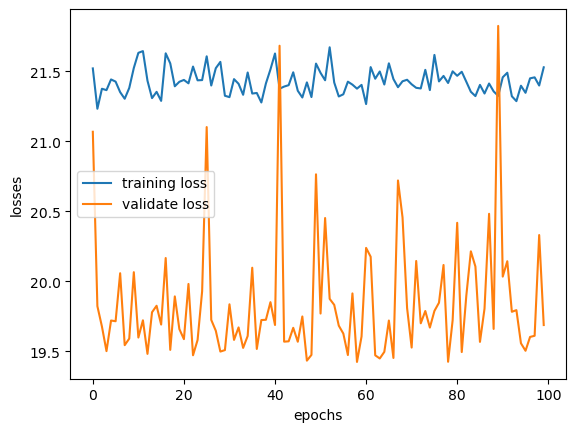

In [35]:
loss_df = pd.DataFrame({
    "training loss" : train_losses,
    "validate loss" : val_losses
})

plt.plot(loss_df["training loss"] , label ="training loss" )
plt.plot(loss_df["validate loss"] , label ="validate loss" )

plt.xlabel("epochs")
plt.ylabel("losses")

plt.legend()


In [36]:
#  load the data
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [37]:
#evalution
model.eval()

with torch.no_grad():
    train_preds = model(x_train_tensor)
    test_preds = model(x_test_tensor)

    train_mse_loss = criterion(train_preds , x_train_tensor)
    test_mse_loss = criterion(test_preds , x_test_tensor)

print("training mse: ",train_mse_loss.item())
print("test mse: ",test_mse_loss.item())

training mse:  206538.3125
test mse:  206539.28125


C:\Users\HP\anaconda3\New folder\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([7654, 4])) that is different to the input size (torch.Size([7654, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
C:\Users\HP\anaconda3\New folder\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([1914, 4])) that is different to the input size (torch.Size([1914, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [30]:
from sklearn.metrics import r2_score

In [31]:
print("r2_score:",r2_score(y_test,test_preds) )

r2_score: 0.9311773465189941


In [40]:
predicted_df = pd.DataFrame(test_preds.numpy() , columns = ["predicted_values"])
actual_df = pd.DataFrame(y_test.values, columns = ["actual_values_values"])

pd.concat([predicted_df,actual_df],axis = 1)

,predicted_values,actual_values_values
0,435.318573,433.27
1,437.064026,438.16
2,461.304993,458.42
3,476.079437,480.82
4,435.806427,441.41
...,...,...
1909,451.057190,456.70
1910,431.764923,438.04
1911,467.348206,467.80
1912,431.291779,437.14
